# Factory-to-Customer Shipping Route Efficiency Analysis
### Nassau Candy Distributor — Exploratory Data Analysis Notebook

This notebook walks through the same cleaning, feature engineering, and analysis steps used by
`app.py`, but as a linear, step-by-step exploration rather than an interactive dashboard. It's meant
to be read top to bottom, and every cell can be re-run against a refreshed CSV export in `data/`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="darkgrid")

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/Nassau_Candy_Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
df.shape

(10194, 18)

In [4]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [6]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 3. Data Cleaning

Order Date and Ship Date come in as day-first strings (`dd-mm-yyyy`), and the numeric fields need
to be coerced in case any stray text sneaks into an export. We also drop any row that ends up
missing a core field after coercion.

In [9]:
df_clean = df.copy()

df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"], dayfirst=True, errors="coerce")
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"], dayfirst=True, errors="coerce")

for col in ["Sales", "Units", "Gross Profit", "Cost"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

before = len(df_clean)
df_clean = df_clean.dropna(subset=["Order Date", "Ship Date", "Sales", "Units", "Gross Profit"])
after = len(df_clean)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows dropped:         {before - after}")

Rows before cleaning: 10194
Rows after cleaning:  10194
Rows dropped:         0


In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

## 4. Feature Engineering

### 4.1 Shipping Lead Time
The core KPI for this whole project: the number of days between an order being placed and it
shipping out.

In [11]:
df_clean["Lead Time"] = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days
df_clean["Lead Time"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [12]:
# a negative lead time would mean the shipment left before it was even ordered - not physically
# possible, so we treat it as bad data and drop it
negative_lead_times = (df_clean["Lead Time"] < 0).sum()
print(f"Negative lead time rows found: {negative_lead_times}")

df_clean = df_clean[df_clean["Lead Time"] >= 0]
print(f"Rows remaining: {len(df_clean)}")

Negative lead time rows found: 0
Rows remaining: 10194


### 4.2 Factory Mapping & Routes

The dataset doesn't include a factory column directly, so we attach one using the fixed
product-to-factory lookup table supplied with the project brief. Every one of the 15 products maps
to exactly one of 5 factories.

In [13]:
PRODUCT_FACTORY_MAP = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory",
}

FACTORY_COORDS = {
    "Lot\'s O\' Nuts":     {"lat": 32.881893, "lon": -111.768036},
    "Wicked Choccy\'s":   {"lat": 32.076176, "lon": -81.088371},
    "Sugar Shack":       {"lat": 48.119140, "lon": -96.181150},
    "Secret Factory":    {"lat": 41.446333, "lon": -90.565487},
    "The Other Factory": {"lat": 35.117500, "lon": -89.971107},
}

df_clean["Factory"] = df_clean["Product Name"].map(PRODUCT_FACTORY_MAP)

unmapped = df_clean["Factory"].isnull().sum()
print(f"Products that failed to map to a factory: {unmapped}")

df_clean["Route (State)"] = df_clean["Factory"] + " -> " + df_clean["State/Province"]
df_clean["Route (Region)"] = df_clean["Factory"] + " -> " + df_clean["Region"]

df_clean[["Product Name", "Factory", "State/Province", "Route (State)"]].head()

Products that failed to map to a factory: 0


,Product Name,Factory,State/Province,Route (State)
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Texas,Wicked Choccy's -> Texas
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Illinois,Wicked Choccy's -> Illinois
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Illinois,Lot's O' Nuts -> Illinois
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Illinois,Lot's O' Nuts -> Illinois
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Pennsylvania,Wicked Choccy's -> Pennsylvania


### 4.3 Calendar Features

In [14]:
df_clean["Order Month"] = df_clean["Order Date"].dt.month_name()
df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Order Quarter"] = df_clean["Order Date"].dt.quarter
df_clean["Order Weekday"] = df_clean["Order Date"].dt.day_name()

df_clean[["Order Date", "Order Month", "Order Year", "Order Quarter", "Order Weekday"]].head()

,Order Date,Order Month,Order Year,Order Quarter,Order Weekday
0,2024-01-03,January,2024,1,Wednesday
1,2024-01-04,January,2024,1,Thursday
2,2024-01-04,January,2024,1,Thursday
3,2024-01-04,January,2024,1,Thursday
4,2024-01-05,January,2024,1,Friday


## 5. Overall Shipping Performance

In [15]:
total_shipments = len(df_clean)
avg_lead_time = df_clean["Lead Time"].mean()
median_lead_time = df_clean["Lead Time"].median()
lead_time_std = df_clean["Lead Time"].std()

print(f"Total shipments:          {total_shipments:,}")
print(f"Average lead time:        {avg_lead_time:,.1f} days")
print(f"Median lead time:         {median_lead_time:,.1f} days")
print(f"Lead time std deviation:  {lead_time_std:,.1f} days")

Total shipments:          10,194
Average lead time:        1,320.8 days
Median lead time:         1,274.0 days
Lead time std deviation:  262.4 days


In [16]:
delay_threshold = df_clean["Lead Time"].quantile(0.75)
delay_rate = (df_clean["Lead Time"] > delay_threshold).mean() * 100

print(f"Delay threshold (75th percentile): {delay_threshold:.0f} days")
print(f"Overall delay rate: {delay_rate:.1f}%")

Delay threshold (75th percentile): 1638 days
Overall delay rate: 21.1%


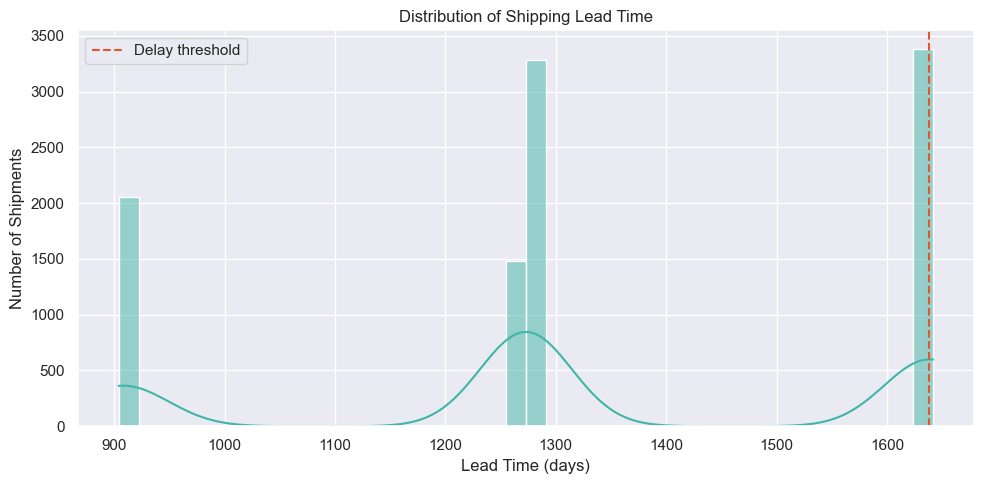

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["Lead Time"], bins=40, kde=True, color="#3FB6A8")
plt.axvline(delay_threshold, color="#E4572E", linestyle="--", label="Delay threshold")
plt.title("Distribution of Shipping Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Shipments")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Ship Mode Comparison

In [18]:
mode_stats = (
    df_clean.assign(Delayed=df_clean["Lead Time"] > delay_threshold)
    .groupby("Ship Mode")
    .agg(
        Shipments=("Order ID", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Lead_Time_Std=("Lead Time", "std"),
        Delay_Rate=("Delayed", "mean"),
    )
    .reset_index()
)
mode_stats["Delay_Rate"] = mode_stats["Delay_Rate"] * 100
mode_stats = mode_stats.sort_values("Avg_Lead_Time")
mode_stats

,Ship Mode,Shipments,Avg_Lead_Time,Lead_Time_Std,Delay_Rate
3,Standard Class,6120,1314.334641,262.400116,30.898693
2,Second Class,1979,1323.845376,261.813569,12.935826
1,Same Day,547,1333.442413,253.813374,0.000000
0,First Class,1548,1338.275840,265.632140,0.000000


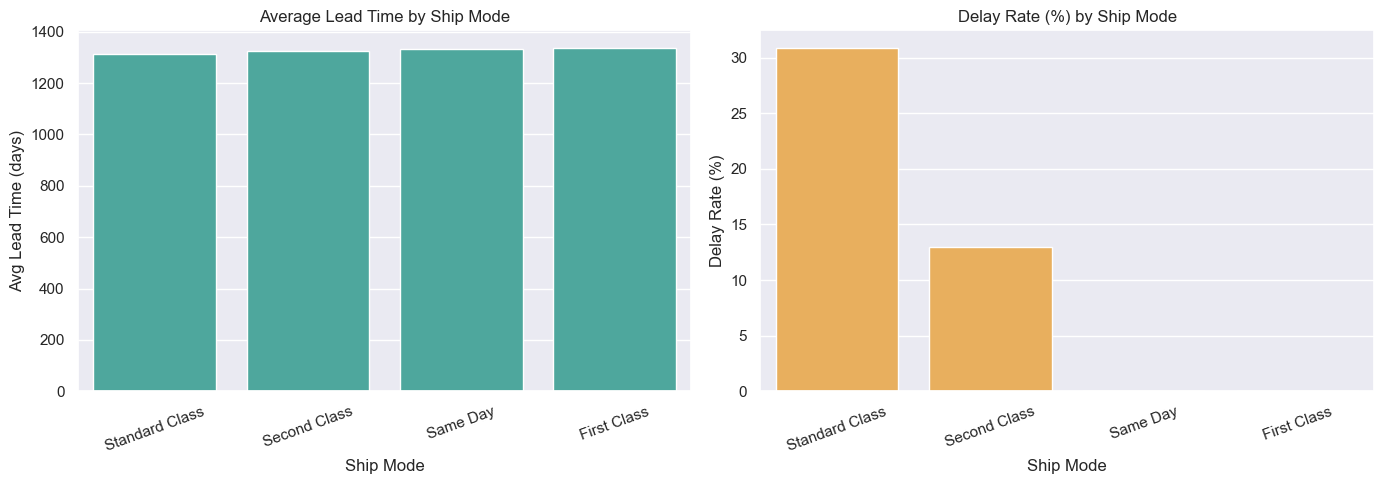

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=mode_stats, x="Ship Mode", y="Avg_Lead_Time", ax=axes[0], color="#3FB6A8")
axes[0].set_title("Average Lead Time by Ship Mode")
axes[0].set_ylabel("Avg Lead Time (days)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=mode_stats, x="Ship Mode", y="Delay_Rate", ax=axes[1], color="#FFB347")
axes[1].set_title("Delay Rate (%) by Ship Mode")
axes[1].set_ylabel("Delay Rate (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 7. Regional Comparison

In [20]:
region_stats = (
    df_clean.groupby("Region")
    .agg(Shipments=("Order ID", "count"), Avg_Lead_Time=("Lead Time", "mean"))
    .reset_index()
    .sort_values("Avg_Lead_Time")
)
region_stats

,Region,Shipments,Avg_Lead_Time
1,Gulf,1620,1311.374691
3,Pacific,3253,1322.194897
0,Atlantic,2986,1322.745144
2,Interior,2335,1323.091221


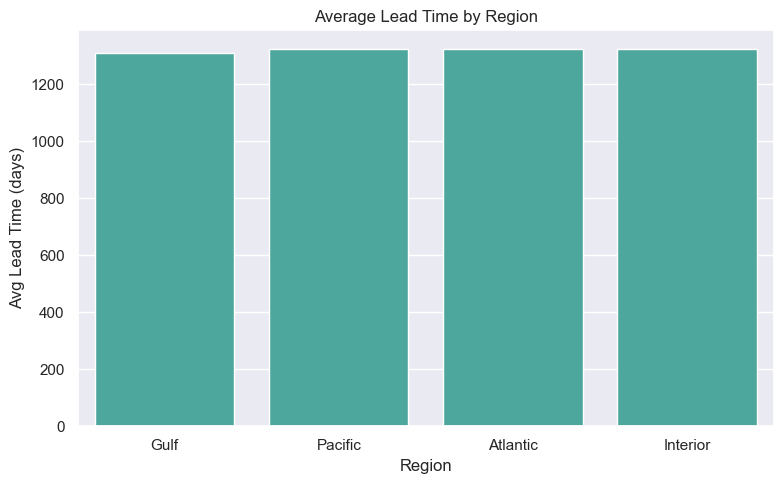

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=region_stats, x="Region", y="Avg_Lead_Time", color="#3FB6A8")
plt.title("Average Lead Time by Region")
plt.ylabel("Avg Lead Time (days)")
plt.tight_layout()
plt.show()

## 8. Route Efficiency Leaderboard

We restrict to routes with at least 10 shipments so the ranking isn't dominated by routes that
only appear once or twice.

In [22]:
route_stats = (
    df_clean.groupby("Route (State)")
    .agg(
        Shipments=("Order ID", "count"),
        Avg_Lead_Time=("Lead Time", "mean"),
        Lead_Time_Std=("Lead Time", "std"),
    )
    .reset_index()
)
route_stats["Lead_Time_Std"] = route_stats["Lead_Time_Std"].fillna(0)

route_stats_min10 = route_stats[route_stats["Shipments"] >= 10].copy()

min_lt, max_lt = route_stats_min10["Avg_Lead_Time"].min(), route_stats_min10["Avg_Lead_Time"].max()
route_stats_min10["Efficiency Score"] = 100 * (1 - (route_stats_min10["Avg_Lead_Time"] - min_lt) / (max_lt - min_lt))

print(f"Total distinct routes: {route_stats['Route (State)'].nunique()}")
print(f"Routes with >= 10 shipments: {len(route_stats_min10)}")

Total distinct routes: 196
Routes with >= 10 shipments: 96


In [23]:
top10 = route_stats_min10.sort_values("Avg_Lead_Time").head(10)
top10

,Route (State),Shipments,Avg_Lead_Time,Lead_Time_Std,Efficiency Score
168,Wicked Choccy's -> Nevada,12,1182.250000,226.373033,100.000000
90,Secret Factory -> Texas,16,1227.062500,323.908314,85.385593
52,Lot's O' Nuts -> Virginia,109,1229.486239,262.008609,84.595155
186,Wicked Choccy's -> South Carolina,19,1234.210526,240.899144,83.054454
50,Lot's O' Nuts -> Utah,29,1236.000000,298.219718,82.470865
192,Wicked Choccy's -> Virginia,106,1238.877358,254.774025,81.532491
164,Wicked Choccy's -> Mississippi,22,1240.454545,222.889622,81.018133
29,Lot's O' Nuts -> Nevada,24,1243.250000,239.222336,80.106470
183,Wicked Choccy's -> Quebec,24,1243.583333,322.092738,79.997762
41,Lot's O' Nuts -> Oregon,77,1245.194805,269.878630,79.472223


In [24]:
bottom10 = route_stats_min10.sort_values("Avg_Lead_Time", ascending=False).head(10)
bottom10

,Route (State),Shipments,Avg_Lead_Time,Lead_Time_Std,Efficiency Score
172,Wicked Choccy's -> New Mexico,17,1488.882353,226.430420,0.000000
15,Lot's O' Nuts -> Iowa,16,1479.000000,187.511777,3.222867
94,Secret Factory -> Washington,11,1472.363636,190.502637,5.387141
33,Lot's O' Nuts -> New Mexico,18,1456.944444,258.263083,10.415701
159,Wicked Choccy's -> Manitoba,10,1455.600000,192.900780,10.854156
7,Lot's O' Nuts -> Connecticut,47,1420.553191,249.385750,22.283742
154,Wicked Choccy's -> Iowa,14,1403.785714,272.001465,27.752009
153,Wicked Choccy's -> Indiana,54,1402.462963,257.765340,28.183389
188,Wicked Choccy's -> Tennessee,67,1393.761194,241.358283,31.021240
48,Lot's O' Nuts -> Tennessee,109,1390.963303,257.716321,31.933698


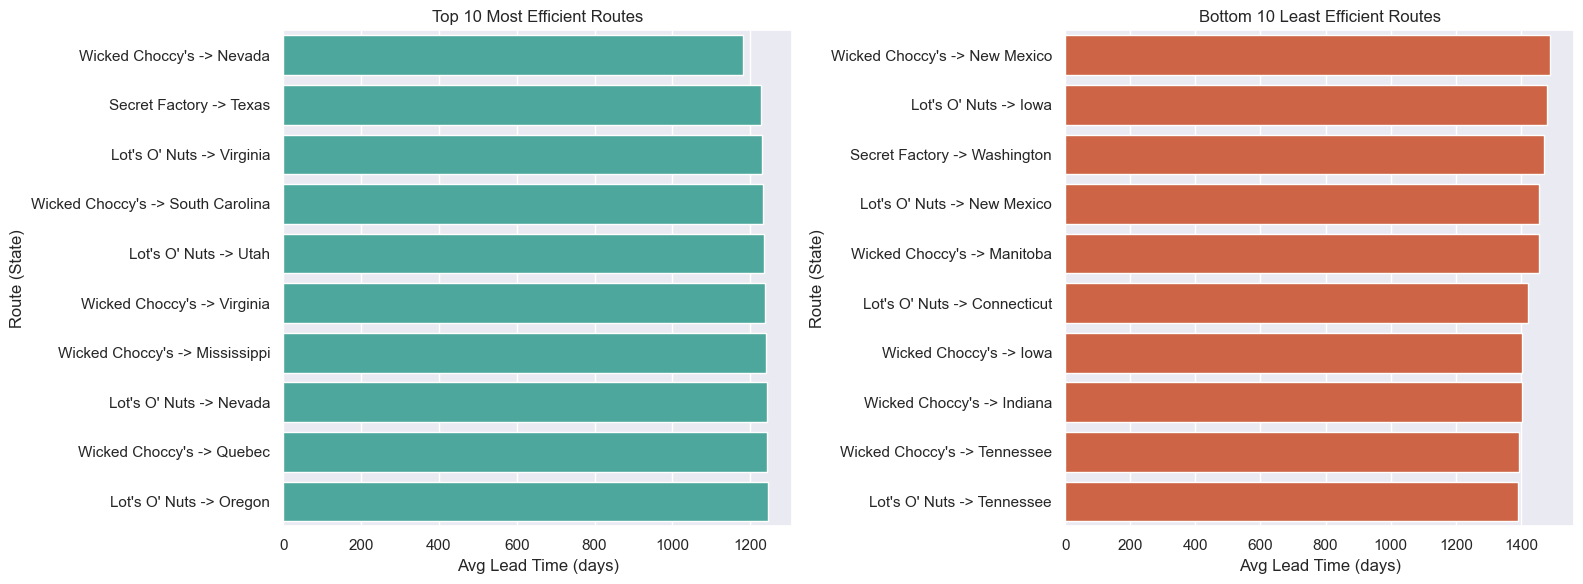

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top10, y="Route (State)", x="Avg_Lead_Time", ax=axes[0], color="#3FB6A8")
axes[0].set_title("Top 10 Most Efficient Routes")
axes[0].set_xlabel("Avg Lead Time (days)")

sns.barplot(data=bottom10, y="Route (State)", x="Avg_Lead_Time", ax=axes[1], color="#E4572E")
axes[1].set_title("Bottom 10 Least Efficient Routes")
axes[1].set_xlabel("Avg Lead Time (days)")

plt.tight_layout()
plt.show()

## 9. Geographic Bottleneck Analysis

A state is flagged as a bottleneck if it has **both** above-average shipment volume **and**
above-average lead time compared to all other states — these are the routes worth investigating
first, since they combine scale with poor performance.

In [26]:
state_stats = (
    df_clean.groupby("State/Province")
    .agg(Shipments=("Order ID", "count"), Avg_Lead_Time=("Lead Time", "mean"))
    .reset_index()
)

avg_shipments = state_stats["Shipments"].mean()
avg_state_lead_time = state_stats["Avg_Lead_Time"].mean()

bottlenecks = state_stats[
    (state_stats["Avg_Lead_Time"] > avg_state_lead_time) &
    (state_stats["Shipments"] > avg_shipments)
].sort_values("Avg_Lead_Time", ascending=False)

print(f"Average shipments per state: {avg_shipments:.1f}")
print(f"Average lead time per state: {avg_state_lead_time:.1f} days")
print()
bottlenecks

Average shipments per state: 172.8
Average lead time per state: 1328.6 days



,State/Province,Shipments,Avg_Lead_Time
50,Tennessee,183,1391.486339
55,Washington,506,1360.662055
11,Georgia,184,1338.635870
6,Colorado,182,1337.186813
36,North Carolina,249,1334.883534


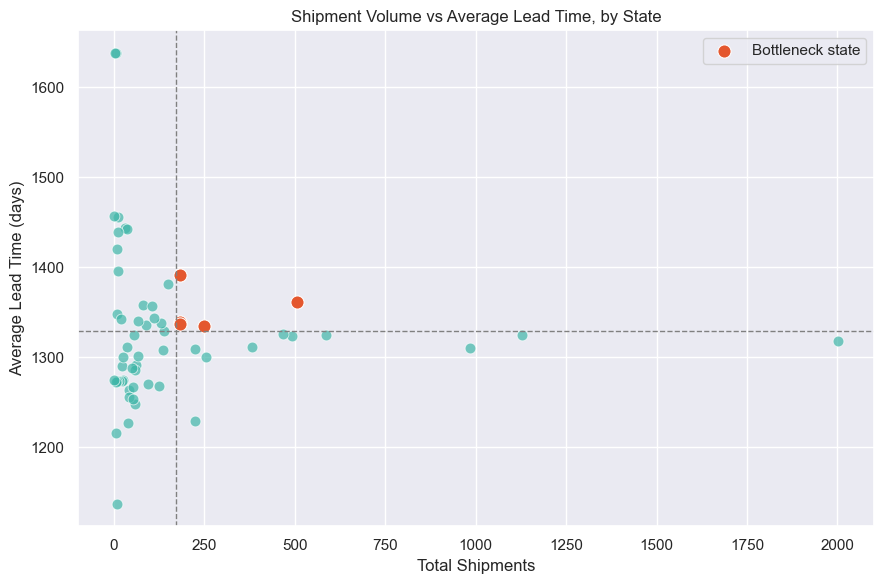

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=state_stats, x="Shipments", y="Avg_Lead_Time",
    color="#3FB6A8", s=60, alpha=0.7
)
sns.scatterplot(
    data=bottlenecks, x="Shipments", y="Avg_Lead_Time",
    color="#E4572E", s=90, label="Bottleneck state"
)
plt.axhline(avg_state_lead_time, color="gray", linestyle="--", linewidth=1)
plt.axvline(avg_shipments, color="gray", linestyle="--", linewidth=1)
plt.title("Shipment Volume vs Average Lead Time, by State")
plt.xlabel("Total Shipments")
plt.ylabel("Average Lead Time (days)")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Does Order Value Affect Shipping Speed?

In [28]:
corr = df_clean[["Sales", "Units", "Gross Profit", "Cost", "Lead Time"]].corr()
corr

,Sales,Units,Gross Profit,Cost,Lead Time
Sales,1.000000,0.729347,0.976404,0.958986,-0.005438
Units,0.729347,1.000000,0.815820,0.563344,-0.006702
Gross Profit,0.976404,0.815820,1.000000,0.875144,-0.003305
Cost,0.958986,0.563344,0.875144,1.000000,-0.007846
Lead Time,-0.005438,-0.006702,-0.003305,-0.007846,1.000000


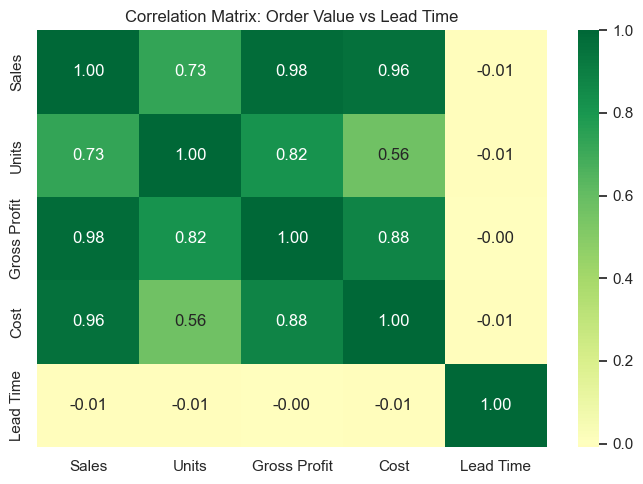

In [29]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation Matrix: Order Value vs Lead Time")
plt.tight_layout()
plt.show()

Every correlation between Lead Time and the financial fields sits within a hair of zero,
meaning bigger or more valuable orders aren't shipped any faster (or slower) than smaller ones.

## 11. Divisional & Factory Contribution

In [30]:
division_stats = (
    df_clean.groupby("Division")
    .agg(Shipments=("Order ID", "count"), Sales=("Sales", "sum"), Profit=("Gross Profit", "sum"))
    .sort_values("Sales", ascending=False)
)
division_stats

,Shipments,Sales,Profit
Division,,,
Chocolate,9844,131692.90,88824.62
Other,310,9663.25,4333.45
Sugar,40,427.48,284.73


In [31]:
factory_counts = df_clean["Factory"].value_counts()
factory_share = (factory_counts / factory_counts.sum() * 100).round(1)

pd.DataFrame({"Shipments": factory_counts, "Share (%)": factory_share})

,Shipments,Share (%)
Factory,,
Lot's O' Nuts,5692,55.8
Wicked Choccy's,4152,40.7
Secret Factory,217,2.1
The Other Factory,100,1.0
Sugar Shack,33,0.3


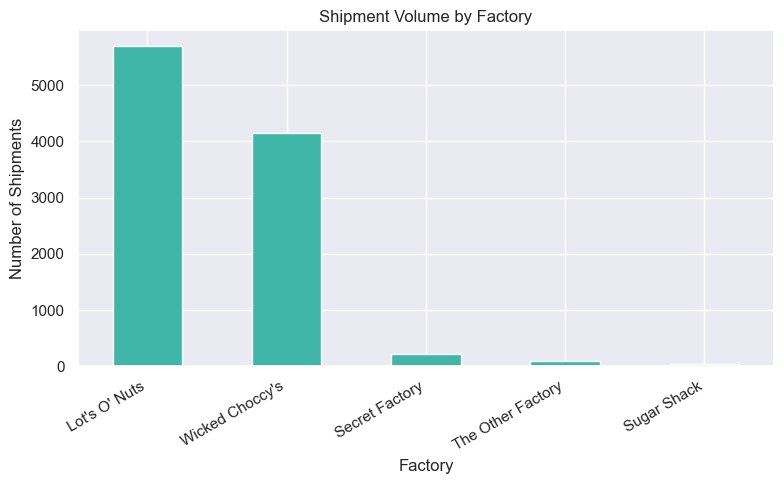

In [32]:
plt.figure(figsize=(8, 5))
factory_counts.plot(kind="bar", color="#3FB6A8")
plt.title("Shipment Volume by Factory")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 12. Summary

- Two factories, **Lot's O' Nuts** and **Wicked Choccy's**, account for roughly 96% of all shipment
  volume — overall performance numbers mostly reflect these two sites.
- **Standard Class** is both the highest-volume and (on average) fastest ship mode; **First Class**
  is the slowest, which is worth a second look operationally.
- Regional differences in lead time are small; route-level and state-level differences are much
  larger, which is why the route leaderboard (Section 8) is more actionable than the regional
  summary (Section 7) on its own.
- A handful of states combine high volume with high lead time (Section 9) — these are the clearest
  candidates for a process review.
- Order value has no meaningful relationship with shipping speed (Section 10).

The full write-up of these findings, along with business recommendations, lives in
`docs/Research_Paper.docx` and `docs/Executive_Summary.docx`. The same logic that powers this
notebook also powers the interactive dashboard in `app.py` — run `streamlit run app.py` to explore
it with live filters.